# Exercise 4

## Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

## Task 1
(3 points)

Implement the training loop for one training epoch.
An epoch trains on the whole training dataset once.

In [2]:
def train(model, use_cuda, train_loader, optimizer, epoch, log_interval):
    """
    Train one epoch
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    train_loader -- data loader
    optimizer -- network optimizer
    epoch -- number of current epoch
    log_interval -- number of training steps between logs
    """
    # TODO: set the model to train mode
    model.train()
    
    
    # TODO: enumerate over the dataloader to get mini batches
    #       of images and ground truth labels
    # HINT: the builtin python function enumerate() also gives you indices
    for batch_idx, (data, target) in enumerate(train_loader):
        
        if use_cuda:
            data, target = data.cuda(), target.cuda()
        
        # TODO: set the optimizers gradients to zero
        optimizer.zero_grad()
        
        # TODO: run the network
        output = model(data)
        
        # TODO: compute negative log likelihood loss
        loss = F.nll_loss(output, target)
        
        
        # TODO: do backpropagation
        loss.backward()
        
        # TODO: optimize
        optimizer.step()
        
        # TODO: print current loss for every nth ("log_interval"th) iteration
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

We already implemented the validation function for you (this is essentially validate() from the last exercise)

In [3]:
def validate(model, use_cuda, test_loader):
    """
    Compute test metrics
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    test_loader -- data loader
    """
    # create a 10x10 grid of subplots
    _, axis = plt.subplots(10, 10)
    
    # set model to evaluation mode
    model.eval()
    test_loss = 0
    correct = 0
    plotted = 0
    
    # disable gradients globally
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            # for each batch
            if use_cuda:
                # transfer to GPU
                data = data.cuda()
                target = target.cuda()
            
            # run network and compute metrics
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            
            img_correct = pred.eq(target.view_as(pred))
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            # plot the first 100 images
            img_idx = 0
            data = data.cpu().numpy()
            
            while plotted < 100 and img_idx < data.shape[0]:
                # compute position of ith image in the grid
                y = plotted % 10
                x = plotted // 10
                
                # convert image tensor to numpy array and normalize to [0, 1]
                img = data[img_idx, 0]
                img = (img - np.min(img)) / (np.max(img) - np.min(img))
                
                # make wrongly predicted images red
                img = np.stack([img] * 3, 2)
                if img_correct[img_idx] == 0:
                    img[:, :, 1:] = 0.0
                
                # disable axis and show image
                axis[y][x].axis('off')
                axis[y][x].imshow(img)
                
                # show the predicted class next to each image
                axis[y][x].text(30, 25, pred[img_idx].item())
                
                plotted += 1
                img_idx += 1
            
    test_loss /= len(test_loader.dataset)

    # show results
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    plt.show()

## Task 2
(4 points)

Implement a five-layer fully connected neural network.
The dimensions (without batch size) should change like this: 784->200->100->60->30->10
Use log softmax to compute the class predictions.

Run the code at the end of the notebook to train and validate your implementation.

### Task 2.1
* sigmoid non-linear activation function
* note that the last layer does not need an activation function!

### Task 2.2
* add a new class "FCNet2"
* replace sigmoid with ReLU

### Task 2.3
* add a new class "FCNet2"
* add batch normalization to the first and third layers (note the difference between 1D/2D/3D versions)


**NOTE:** The perfomance should improve slightly with each step. However, due to the random weight initialization applied by PyTorch, your results may vary a bit between trainings.

In [4]:
class FCNet1(nn.Module):
    """
    Fully Connected Neural Network
    
    Five fully connected layers with sigmoid non-linearity
    
    Dimensions
    784->200->100->60->30->10
    """
    def __init__(self):
        super(FCNet1, self).__init__()
        
        # TODO: initialize network layers
        # HINT: take a look at "torch.nn" (imported as "nn")
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)
       

    def forward(self, x):
        # TODO: reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1)
        
        
        # TODO: run network layers
        x = F.sigmoid(self.fc1(x))
        x = F.sigmoid(self.fc2(x))
        x = F.sigmoid(self.fc3(x))
        x = F.sigmoid(self.fc4(x))
        output = self.fc5(x)
        
        
        # TODO: compute log softmax over the output
        # HINT: take a look at "torch.nn.functional" (imported as "F")
        output = F.log_softmax(output, dim=1)
        
        
        return output

In [5]:
class FCNet2(nn.Module):
    def __init__(self):
        super(FCNet2, self).__init__()
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        output = self.fc5(x)
        output = F.log_softmax(output, dim=1)
        return output

In [6]:
class FCNet3(nn.Module):
    def __init__(self):
        super(FCNet3, self).__init__()
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)
        self.bn1 = nn.BatchNorm1d(200)
        self.bn3 = nn.BatchNorm1d(60)
        
    def forward(self, x):        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.bn1(x)
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.bn3(x)
        x = F.relu(self.fc4(x))
        output = self.fc5(x)
        output = F.log_softmax(output, dim=1)
        return output

## Task 3
(3 points)

Implement a convolutional neural network, consisting of two convolutional and two fully connected layers.
This time, the dimensions (without batch size) should change like this: 1x28x28->32x26x26->64x12x12->128->10

### Task 3.1
* two convolutional layers (kernel size 3)
* two fully-connected layers
* ReLU activation function

### Task 3.2
* add batch normalization to first convolutional and first fully connected layer

### Task 3.3
* use max pooling instead of stride to reduce the dimensions to 64x12x12

In [7]:
class ConvNet1(nn.Module):
    """
    Convolutional Neural Network
    
    Two convolutional layers and two fully connected layers
    
    Dimensions:
    1x28x28->32x26x26->64x12x12->128->10
    """
    def __init__(self):
        super(ConvNet1, self).__init__()
        
        # TODO: initialize network layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)
        

    def forward(self, x):
        # TODO: run convolutional layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        
        # TODO: reshape batch of images to batch of 1D vectors
        x = torch.flatten(x, 1)
        
        
        # TODO: run fully connected layers
        x = F.relu(self.fc1(x))
        output = self.fc2(x)
        
        # TODO: compute log softmax over the output
        output = F.log_softmax(output, dim=1)
        
        
        return output

In [8]:
class ConvNet2(nn.Module):
    def __init__(self):
        super(ConvNet2, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)
        

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.bn1(x)
        x = F.relu(self.conv2(x))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.bn2(x)
        output = self.fc2(x)
        output = F.log_softmax(output, dim=1)
        
        
        return output

In [9]:
class ConvNet3(nn.Module):
    def __init__(self):
        super(ConvNet3, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        # x = F.max_pool2d(x, 2)
        x = self.bn1(x)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.bn2(x)
        output = self.fc2(x)
        output = F.log_softmax(output, dim=1)
        
        
        return output

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.273150
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.385735
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.434031
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.212027
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.095341
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.220299
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.057371
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.078771
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.140208
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.187297

Test set: Average loss: 0.1215, Accuracy: 9662/10000 (96.62%)



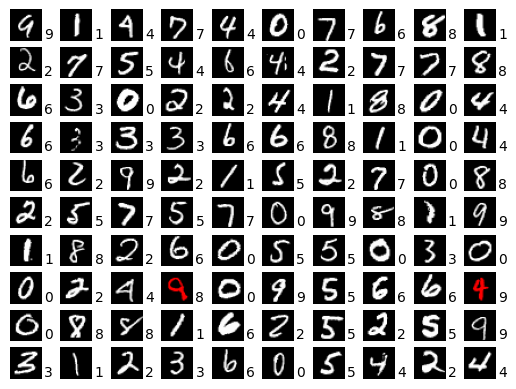

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.043932
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.031046
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.233410
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.060495
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.023326
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.045100
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.080909
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.035356
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.008103
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.039289

Test set: Average loss: 0.0922, Accuracy: 9740/10000 (97.40%)



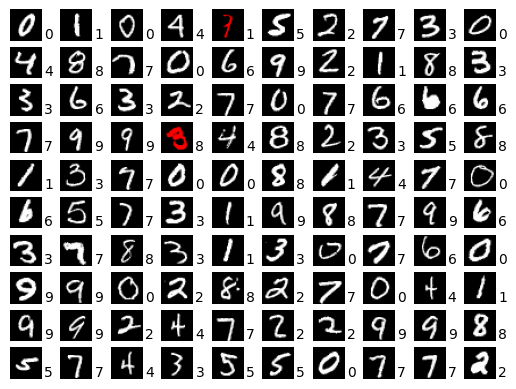

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.076160
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.010879
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.005267
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.010604
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.091363
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.025876
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.037795
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.083917
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.050237
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.021720

Test set: Average loss: 0.0783, Accuracy: 9776/10000 (97.76%)



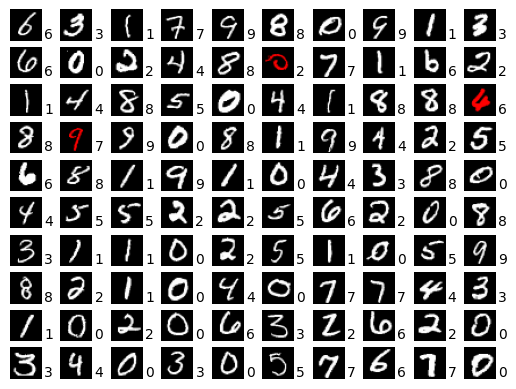

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.023117
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.081401
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.069264
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.150722
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.101902
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.001395
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.001077
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.066771
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.022392
Train Epoch: 4 [57600/60000 (96%)]	Loss: 0.112955

Test set: Average loss: 0.0789, Accuracy: 9788/10000 (97.88%)



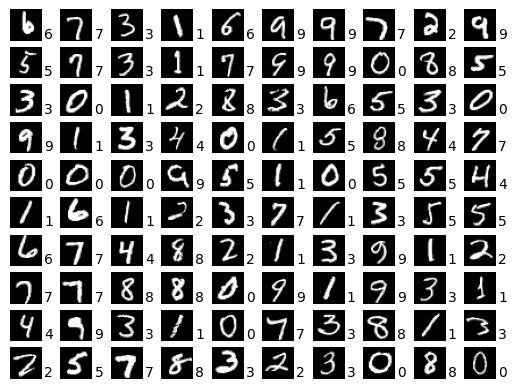

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.007816
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.029952
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.119892
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.005979
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.020972
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.001203
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.073831
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.006198
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.047024
Train Epoch: 5 [57600/60000 (96%)]	Loss: 0.002262

Test set: Average loss: 0.0792, Accuracy: 9804/10000 (98.04%)



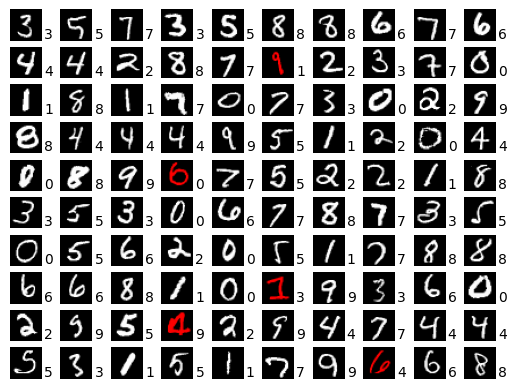

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.006411
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.034753
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.019156
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.001497
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.000587
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.027357
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.009575
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.006074
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.003285
Train Epoch: 6 [57600/60000 (96%)]	Loss: 0.012974

Test set: Average loss: 0.0847, Accuracy: 9803/10000 (98.03%)



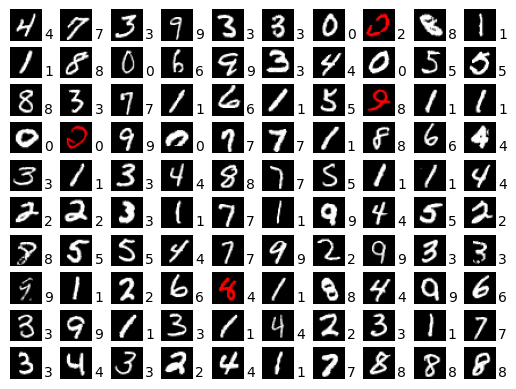

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.000229
Train Epoch: 7 [6400/60000 (11%)]	Loss: 0.015288
Train Epoch: 7 [12800/60000 (21%)]	Loss: 0.000084
Train Epoch: 7 [19200/60000 (32%)]	Loss: 0.004028
Train Epoch: 7 [25600/60000 (43%)]	Loss: 0.004295
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.000773
Train Epoch: 7 [38400/60000 (64%)]	Loss: 0.005718
Train Epoch: 7 [44800/60000 (75%)]	Loss: 0.001096
Train Epoch: 7 [51200/60000 (85%)]	Loss: 0.005714
Train Epoch: 7 [57600/60000 (96%)]	Loss: 0.002128

Test set: Average loss: 0.0808, Accuracy: 9824/10000 (98.24%)



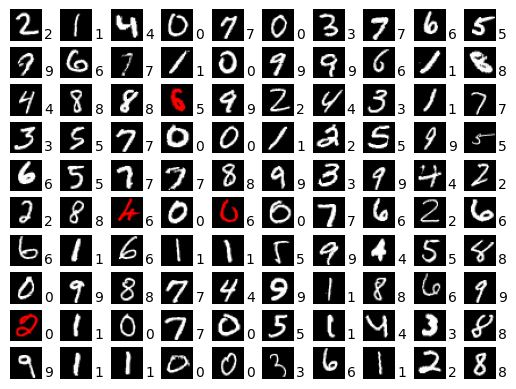

Train Epoch: 8 [0/60000 (0%)]	Loss: 0.000319
Train Epoch: 8 [6400/60000 (11%)]	Loss: 0.009486
Train Epoch: 8 [12800/60000 (21%)]	Loss: 0.000618
Train Epoch: 8 [19200/60000 (32%)]	Loss: 0.004636
Train Epoch: 8 [25600/60000 (43%)]	Loss: 0.100467
Train Epoch: 8 [32000/60000 (53%)]	Loss: 0.000521
Train Epoch: 8 [38400/60000 (64%)]	Loss: 0.000056
Train Epoch: 8 [44800/60000 (75%)]	Loss: 0.003523
Train Epoch: 8 [51200/60000 (85%)]	Loss: 0.000110
Train Epoch: 8 [57600/60000 (96%)]	Loss: 0.003775

Test set: Average loss: 0.0847, Accuracy: 9822/10000 (98.22%)



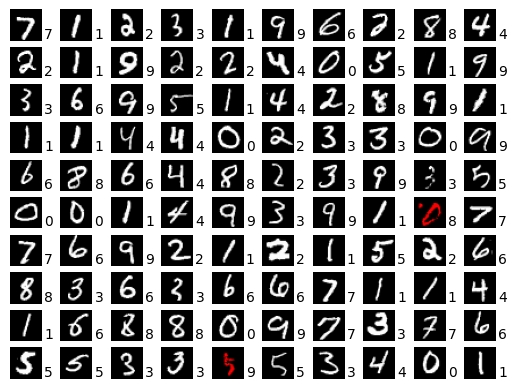

Train Epoch: 9 [0/60000 (0%)]	Loss: 0.000850
Train Epoch: 9 [6400/60000 (11%)]	Loss: 0.000290
Train Epoch: 9 [12800/60000 (21%)]	Loss: 0.002222
Train Epoch: 9 [19200/60000 (32%)]	Loss: 0.000220
Train Epoch: 9 [25600/60000 (43%)]	Loss: 0.012302
Train Epoch: 9 [32000/60000 (53%)]	Loss: 0.009197
Train Epoch: 9 [38400/60000 (64%)]	Loss: 0.001542
Train Epoch: 9 [44800/60000 (75%)]	Loss: 0.001395
Train Epoch: 9 [51200/60000 (85%)]	Loss: 0.000027
Train Epoch: 9 [57600/60000 (96%)]	Loss: 0.000238

Test set: Average loss: 0.0855, Accuracy: 9820/10000 (98.20%)



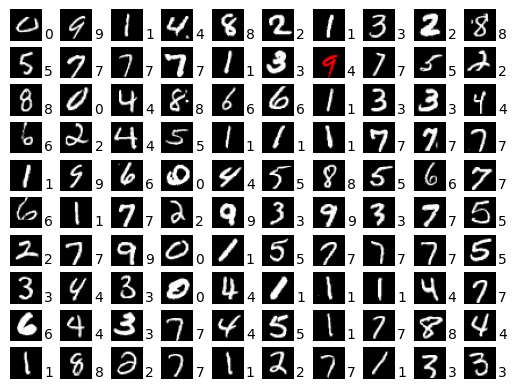

Train Epoch: 10 [0/60000 (0%)]	Loss: 0.000766
Train Epoch: 10 [6400/60000 (11%)]	Loss: 0.005324
Train Epoch: 10 [12800/60000 (21%)]	Loss: 0.002468
Train Epoch: 10 [19200/60000 (32%)]	Loss: 0.000404
Train Epoch: 10 [25600/60000 (43%)]	Loss: 0.005236
Train Epoch: 10 [32000/60000 (53%)]	Loss: 0.001872
Train Epoch: 10 [38400/60000 (64%)]	Loss: 0.001433
Train Epoch: 10 [44800/60000 (75%)]	Loss: 0.004352
Train Epoch: 10 [51200/60000 (85%)]	Loss: 0.000409
Train Epoch: 10 [57600/60000 (96%)]	Loss: 0.000277

Test set: Average loss: 0.0882, Accuracy: 9823/10000 (98.23%)



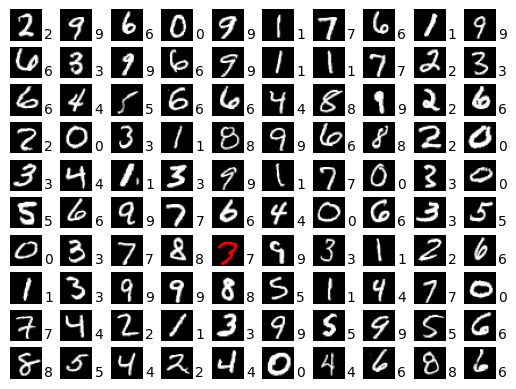

In [10]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)

model = FCNet2()
if use_cuda:
    model = model.cuda()

# initialize optimizer and scheduler
optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, epochs + 1):
    # train one epoch
    train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
    
    # run on test dataset
    validate(model, use_cuda, test_loader)
    scheduler.step()
    
    
    torch.save(model.state_dict(), "models/mnist/checkpoint.pt")

Model: FCNet1, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.353842


c:\Users\Niter\anaconda3\envs\3dcv-students\lib\site-packages\torch\nn\functional.py:1960: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.313474
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.284966
Train Epoch: 1 [19200/60000 (32%)]	Loss: 2.314465
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.308180
Train Epoch: 1 [32000/60000 (53%)]	Loss: 2.307966
Train Epoch: 1 [38400/60000 (64%)]	Loss: 2.214681
Train Epoch: 1 [44800/60000 (75%)]	Loss: 1.808299
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.667351
Train Epoch: 1 [57600/60000 (96%)]	Loss: 1.481085

Test set: Average loss: 1.4653, Accuracy: 4045/10000 (40.45%)



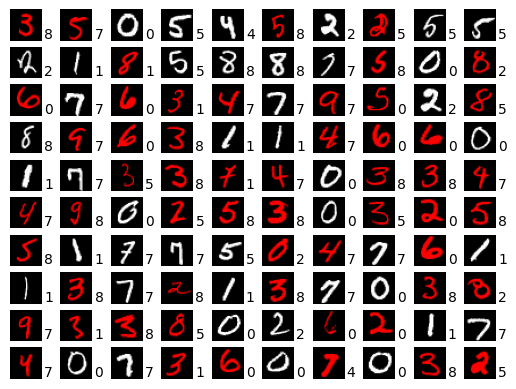

Model: FCNet1, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 1.416619
Train Epoch: 2 [6400/60000 (11%)]	Loss: 1.315963
Train Epoch: 2 [12800/60000 (21%)]	Loss: 1.358801
Train Epoch: 2 [19200/60000 (32%)]	Loss: 1.375961
Train Epoch: 2 [25600/60000 (43%)]	Loss: 1.387994
Train Epoch: 2 [32000/60000 (53%)]	Loss: 1.203670
Train Epoch: 2 [38400/60000 (64%)]	Loss: 1.028564
Train Epoch: 2 [44800/60000 (75%)]	Loss: 1.016417
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.844847
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.839711

Test set: Average loss: 0.8619, Accuracy: 7656/10000 (76.56%)



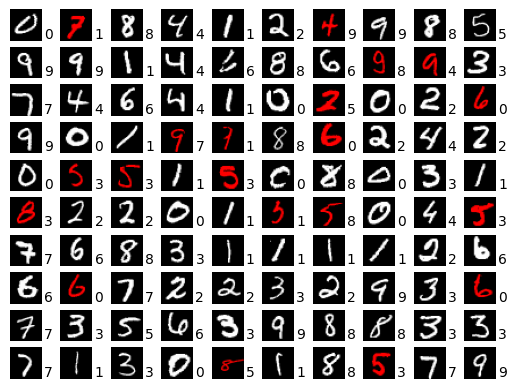

Model: FCNet2, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.308681
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.601261
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.236538
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.128887
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.361193
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.131750
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.166961
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.298339
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.027615
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.089579

Test set: Average loss: 0.1644, Accuracy: 9483/10000 (94.83%)



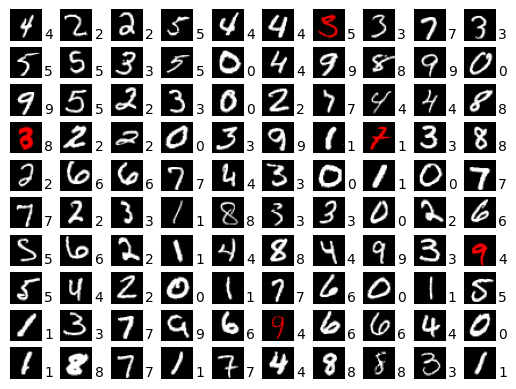

Model: FCNet2, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.194260
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.160291
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.056986
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.175977
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.148546
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.092011
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.029095
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.019355
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.185660
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.032259

Test set: Average loss: 0.0924, Accuracy: 9729/10000 (97.29%)



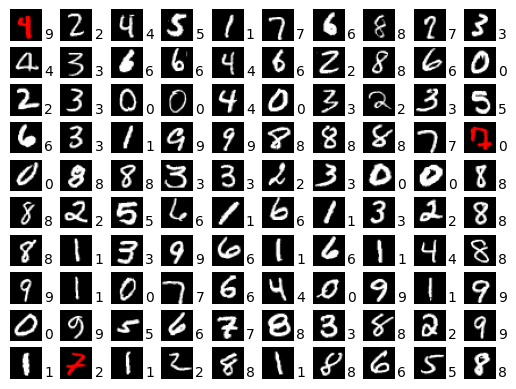

Model: FCNet3, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.299690
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.374147
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.149690
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.188344
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.243746
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.109987
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.234106
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.046022
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.111111
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.061534

Test set: Average loss: 0.1187, Accuracy: 9653/10000 (96.53%)



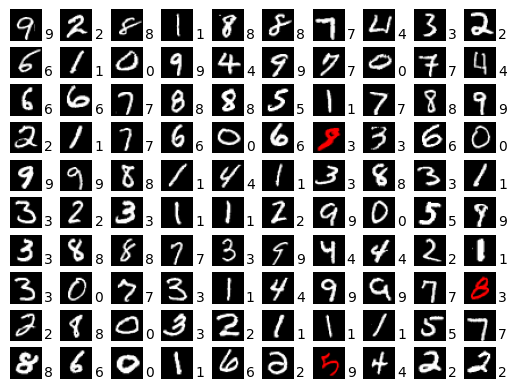

Model: FCNet3, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.236142
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.117252
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.197181
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.082676
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.101438
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.071178
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.066232
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.117928
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.077771
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.084574

Test set: Average loss: 0.0790, Accuracy: 9762/10000 (97.62%)



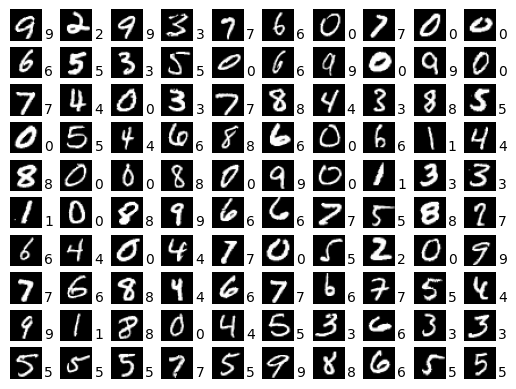

Model: ConvNet1, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.297659
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.193343
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.284383
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.012235
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.122160
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.034679
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.011622
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.063754
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.073911
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.108814

Test set: Average loss: 0.0477, Accuracy: 9846/10000 (98.46%)



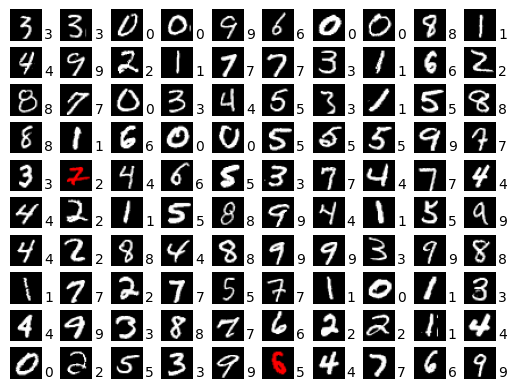

Model: ConvNet1, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.007920
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.008636
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.006777
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.132977
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.013714
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.013557
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.019659
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.002320
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.001746
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.008057

Test set: Average loss: 0.0311, Accuracy: 9889/10000 (98.89%)



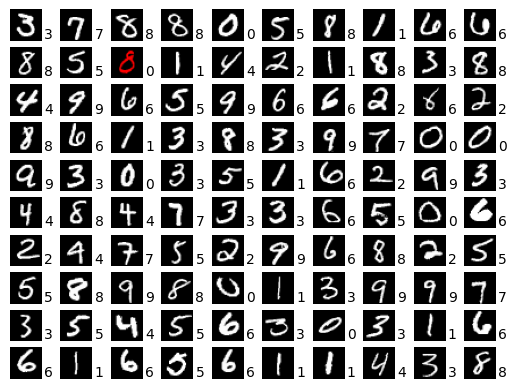

Model: ConvNet2, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.435630
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.126176
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.099108
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.160522
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.050946
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.056031
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.066054
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.060661
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.140006
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.030372

Test set: Average loss: 0.0524, Accuracy: 9825/10000 (98.25%)



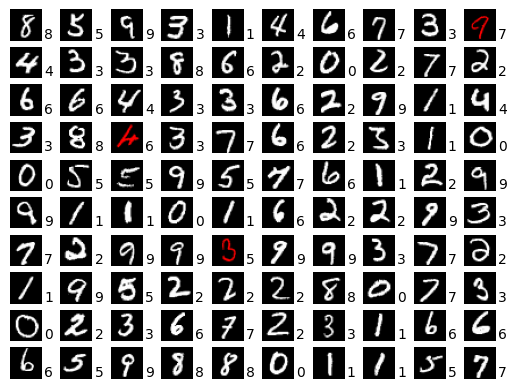

Model: ConvNet2, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.012948
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.045463
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.039529
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.024595
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.021565
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.062297
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.089304
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.061509
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.000856
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.012717

Test set: Average loss: 0.0334, Accuracy: 9891/10000 (98.91%)



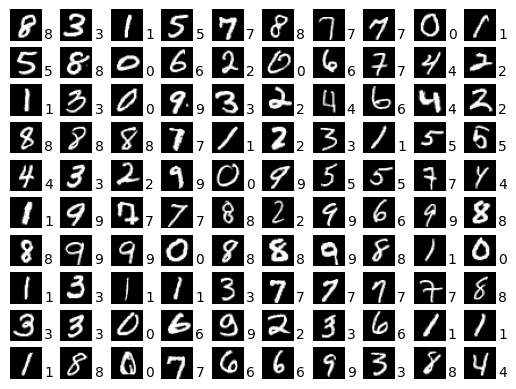

Model: ConvNet3, Epoch: 1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.386724
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.260099
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.089996
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.091814
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.190634
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.017918
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.111650
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.034868
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.017170
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.012227

Test set: Average loss: 0.0459, Accuracy: 9849/10000 (98.49%)



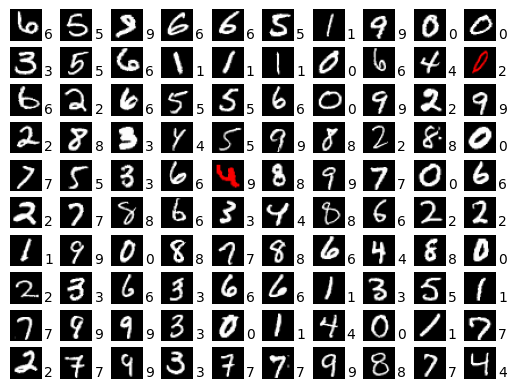

Model: ConvNet3, Epoch: 2
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.036275
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.013450
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.013368
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.010027
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.042396
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.002120
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.013350
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.004557
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.005956
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.001956

Test set: Average loss: 0.0300, Accuracy: 9906/10000 (99.06%)



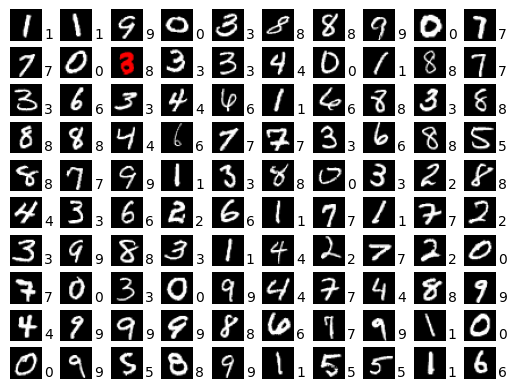

In [11]:
Models = [FCNet1(), FCNet2(), FCNet3(), ConvNet1(), ConvNet2(), ConvNet3()]

epochs = 2

for model in Models:
    
    optimizer = optim.Adadelta(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

    for epoch in range(1, epochs + 1):
        # train one epoch
        print ("Model: {}, Epoch: {}".format(model.__class__.__name__, epoch))
        train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
        
        # run on test dataset
        validate(model, use_cuda, test_loader)
        scheduler.step()